# Linear warp field slices

This notebook plots density and radial-velocity slices at a fixed radius in the global frame and the local disk frame.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.integrate import solve_ivp
from scipy import interpolate
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({"font.size": 22})


/tmp/ipykernel_3461968/1266204598.py:51: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p0 = axs[0, 0].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), rho_2d, **kw_rho)
/tmp/ipykernel_3461968/1266204598.py:52: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p1 = axs[1, 0].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), v_rad_2d, **kw_v)


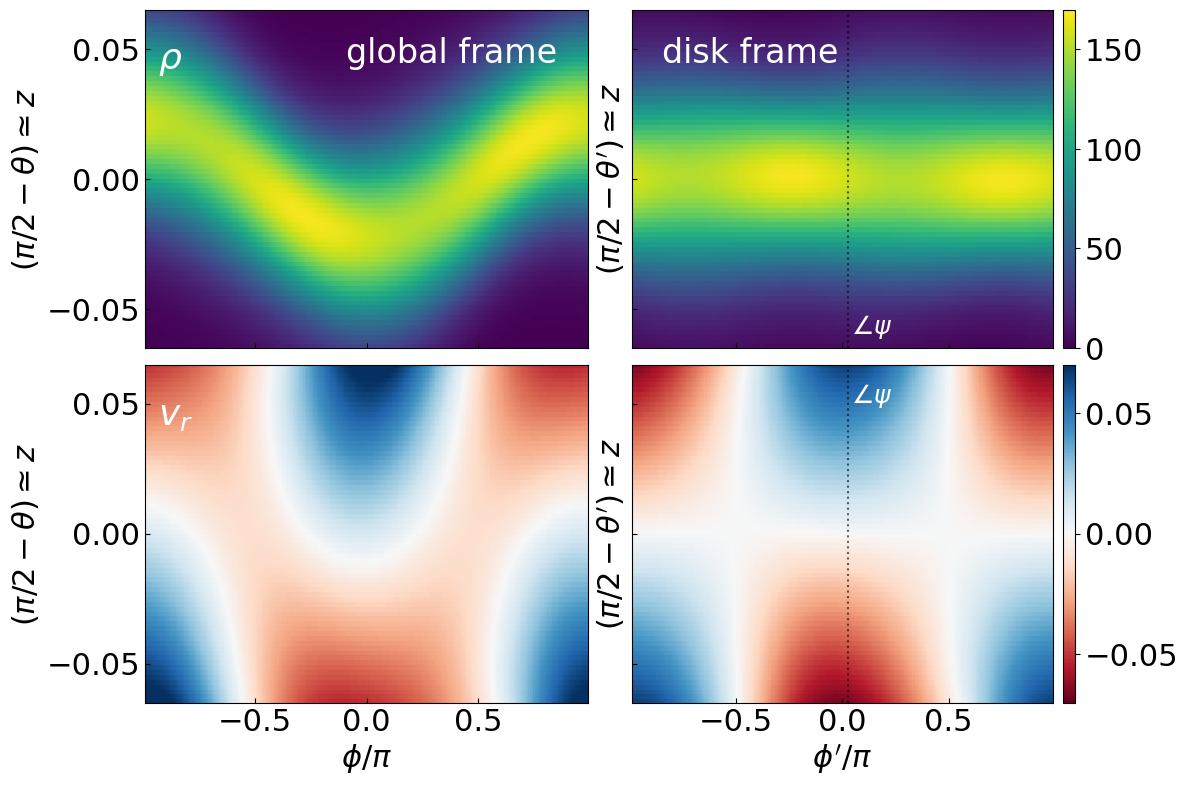

In [2]:
# Plot a 2x2 comparison of the density and radial velocity slices
# in the global frame and the local disk frame at a fixed radius.

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.10)
fig.subplots_adjust(hspace=0.05)

kw_rho = {"vmin": 0, "vmax": 170}
kw_v = {"cmap": "RdBu", "vmin": -7e-2, "vmax": +7e-2}
kw_cax = {"size": "3%", "pad": 0.1}

r_target = 1.5
path = "../data/sim002-const-alpha-t251.200"

res = np.load(path + "-res.npy", allow_pickle=True).item()

# --------------------
# Global frame
# --------------------
data = np.load(path + "-global_field.npy", allow_pickle=True).item()
time = res["profiles"]["t"]

rad_app = res["profiles"]["rad_app"]
tha_mesh = data["tha_3d"]
phi_mesh = data["phi_3d"]

v_rad = data["vr"]
v_phi = data["v_phi"]
v_tha = data["v_tha"]
rho = data["rho"]

ir = np.argmax(rad_app > r_target)

tha_2d = tha_mesh[ir, :, :]
phi_2d = phi_mesh[ir, :, :]
v_rad_2d = v_rad[ir, :, :]
v_phi_2d = v_phi[ir, :, :]
v_tha_2d = v_tha[ir, :, :]
rho_2d = rho[ir, :, :]

v_rad_2d = v_rad_2d - np.mean(v_rad_2d[:, 2:-2], axis=1)[:, np.newaxis]

phi_2d = (phi_2d + np.pi) % (2 * np.pi) - np.pi
i_pi = np.argmax(phi_2d[0, 2:] < 0) + 2

phi_2d = np.roll(phi_2d, shift=i_pi, axis=1)
tha_2d = np.roll(tha_2d, shift=i_pi, axis=1)
rho_2d = np.roll(rho_2d, shift=i_pi, axis=1)
v_rad_2d = np.roll(v_rad_2d, shift=i_pi, axis=1)

p0 = axs[0, 0].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), rho_2d, **kw_rho)
p1 = axs[1, 0].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), v_rad_2d, **kw_v)

# --------------------
# Disk frame
# --------------------
data = np.load(path + "-disk_field.npy", allow_pickle=True).item()
time = res["profiles"]["t"]

rad_app = res["profiles"]["rad_app"]
tha_mesh = data["thap_mesh"]
phi_mesh = data["phip_mesh"]

v_rad = data["v_rad_p"]
v_phi = data["v_phi_p"]
v_tha = data["v_tha_p"]
rho = data["rhop"]

ir = np.argmax(rad_app > r_target)

tha_2d = tha_mesh[ir, :, :]
phi_2d = phi_mesh[ir, :, :]
v_rad_2d = v_rad[ir, :, :]
v_phi_2d = v_phi[ir, :, :]
v_tha_2d = v_tha[ir, :, :]
rho_2d = rho[ir, :, :]

phi_2d = (phi_2d + np.pi) % (2 * np.pi) - np.pi
i_pi = np.argmax(phi_2d[0, :] < 0)

phi_2d = np.roll(phi_2d, shift=i_pi, axis=1)
tha_2d = np.roll(tha_2d, shift=i_pi, axis=1)
rho_2d = np.roll(rho_2d, shift=i_pi, axis=1)
v_rad_2d = np.roll(v_rad_2d, shift=i_pi, axis=1)

p0 = axs[0, 1].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), rho_2d, **kw_rho)
p1 = axs[1, 1].pcolormesh(phi_2d / np.pi, -(tha_2d - 0.5 * np.pi), v_rad_2d, **kw_v)

divider = make_axes_locatable(axs[0, 1])
cax = divider.append_axes("right", **kw_cax)
plt.colorbar(p0, cax=cax)

divider = make_axes_locatable(axs[1, 1])
cax = divider.append_axes("right", **kw_cax)
plt.colorbar(p1, cax=cax)

# --------------------
# Labels and annotations
# --------------------
axs[0, 0].text(0.93, 0.92, r"global frame", c="w", ha="right", va="top",
               transform=axs[0, 0].transAxes, fontsize=24)
axs[0, 1].text(0.07, 0.92, r"disk frame", c="w", ha="left", va="top",
               transform=axs[0, 1].transAxes, fontsize=24)

axs[0, 0].text(0.03, 0.90, r"$\rho$", c="w", ha="left", va="top",
               transform=axs[0, 0].transAxes, fontsize=26)
axs[1, 0].text(0.03, 0.90, r"$v_{r}$", c="w", ha="left", va="top",
               transform=axs[1, 0].transAxes, fontsize=26)

r_sim = res["profiles"]["rad_app"]
l_hat = res["vectors"]["l_hat"]
W_sim = l_hat[0, :] + 1.j * l_hat[1, :]
psi_sim = np.gradient(W_sim, r_sim) * r_sim

G_xyz = res["vectors"]["G_xyz"].copy()
m_hat = res["vectors"]["m_hat"]
n_hat = res["vectors"]["n_hat"]

Gl = np.sum(G_xyz * l_hat, axis=0)
Gm = np.sum(G_xyz * m_hat, axis=0)
Gn = np.sum(G_xyz * n_hat, axis=0)

Gperp = Gm * m_hat + Gn * n_hat
m_sim = -np.angle(psi_sim) / np.pi

for ax in axs[:, 0]:
    ax.set_ylim([-0.065, 0.065])
    ax.set_xlim([-0.99, 0.99])
    ax.tick_params(which="both", direction="in")

for ax in axs[:, 1]:
    ax.set_ylim([-0.065, 0.065])
    ax.set_xlim([-0.99, 0.99])
    ax.tick_params(which="both", direction="in")
    ax.axvline(x=np.interp(r_target, r_sim, m_sim), c="k", ls=":", alpha=0.6)

axs[0, 1].text(0.52, 0.02, r"$\angle \psi$", c="w", ha="left", va="bottom",
               transform=axs[0, 1].transAxes, fontsize=18)
axs[1, 1].text(0.52, 0.95, r"$\angle \psi$", c="w", ha="left", va="top",
               transform=axs[1, 1].transAxes, fontsize=18)

axs[0, 0].set_ylabel(r"$(\pi/2 - \theta) \simeq z$")
axs[1, 0].set_ylabel(r"$(\pi/2 - \theta) \simeq z$")
axs[0, 1].set_ylabel(r"$(\pi/2 - \theta^\prime) \simeq z$")
axs[1, 1].set_ylabel(r"$(\pi/2 - \theta^\prime) \simeq z$")

axs[1, 0].set_xlabel(r"$\phi / \pi$")
axs[1, 1].set_xlabel(r"$\phi^\prime / \pi$")

plt.show()
